# Lista 0: rozgrzewka z krasnalami 🧙‍♂️

**Uczenie maszynowe 2026/2027** · lista bonusowa · nie wymaga wiedzy z wykładu

| Część | Temat | Punkty |
|---|---|---|
| 0 | Co to jest notebook i jak działa Colab | — |
| 1 | Krasnale wrocławskie: numpy, pandas, polars, matplotlib, seaborn, plotly | **2 pkt** (wszystkie zadania 1–5) |
| 2 | Flappy Krasnal: numpy, widgety, numba, pandas, scipy, scikit-learn | **3 pkt** (wszystkie zadania 6–11) |

Punkty są **binarne**: część jest zaliczona, gdy działają *wszystkie* jej zadania. To lista bonusowa — punkty są ponad bazę.

**Oddanie:** pokazujesz uruchomiony notebook prowadzącemu na zajęciach. **Termin:** Część 1 pierwsze zajęcia, część 2 bezterminowo.

Zadania oznaczone są tak: **🎯 Zadanie N**. Pod każdym zadaniem jest komórka ze sprawdzeniem — gdy wszystko gra, dostaniesz pochwałę od krasnala.

> Wszystkie dane o krasnalach są **zmyślone**. Dzielnice są prawdziwe.

## Część 0: notebook i Colab w pigułce

### Co to jest notebook?
Notebook (plik `.ipynb`) to dokument złożony z **komórek**:
- **komórki tekstu** (jak ta) — opis, wzory, obrazki,
- **komórki kodu** — kod w Pythonie, który uruchamiasz, a wynik pojawia się tuż pod nim.

Za notebookiem stoi **jądro** (*kernel*): działający proces Pythona, który **pamięta wszystko**, co do tej pory uruchomiłeś. Konsekwencje:
- liczy się **kolejność uruchamiania**, nie kolejność na ekranie (numer `[5]` obok komórki mówi, którą z kolei uruchomiłeś),
- jeśli zmienisz komórkę wyżej, a nie uruchomisz jej ponownie, Python dalej pamięta starą wersję,
- gdy się pogubisz: zrestartuj jądro i uruchom wszystko od góry.

### Jak uruchomić ten notebook w Google Colab?
1. Wejdź na [colab.research.google.com](https://colab.research.google.com) i zaloguj się kontem Google.
2. **File → Upload notebook** (*Plik → Prześlij notatnik*) i wybierz ten plik `.ipynb`. Możesz też otworzyć go z GitHuba albo z Dysku Google.
3. Uruchamianie:
   - **Shift + Enter** — uruchom komórkę i przejdź do następnej,
   - **Ctrl + Enter** — uruchom komórkę i zostań na miejscu,
   - **Runtime → Run all** (*Środowisko wykonawcze → Uruchom wszystko*) — wszystko od góry,
   - **Runtime → Restart session** — restart jądra (zmienne znikają, pliki zostają).
4. Kod w komórce zaczynający się od `!` to polecenie systemowe (np. `!pip install ...`), a od `%` — tzw. *magic* Jupytera (np. `%timeit`).

### Gdzie śledzić zużycie pamięci (RAM)?
- W prawym górnym rogu Colaba jest wskaźnik **RAM / Dysk**. Kliknij go, żeby zobaczyć szczegóły.
- Darmowy Colab daje ograniczony RAM. Gdy się skończy, sesja się **restartuje** i tracisz wszystkie zmienne.
- Z poziomu kodu: `!free -h` (cały system) albo `df.memory_usage(deep=True).sum()` (jedna ramka danych pandas).

### Jak wrzucać pliki?
- **Panel boczny → ikona folderu 📁 → ikona przesyłania.** Pliki trafiają do katalogu `/content`.
- Z kodu:
  ```python
  from google.colab import files
  uploaded = files.upload()          # otwiera okno wyboru plików
  ```
- Dysk Google (pliki zostają na stałe):
  ```python
  from google.colab import drive
  drive.mount("/content/drive")      # potem: /content/drive/MyDrive/...
  ```
- ⚠️ Pliki w `/content` **znikają**, gdy sesja się zakończy (np. po kilkudziesięciu minutach bezczynności). Ważne rzeczy trzymaj na Dysku albo pobieraj na komputer.
- Colab ma gotowy katalog `sample_data` z kilkoma zbiorami danych do zabawy.

### A bez Colaba?
Lokalnie: `pip install numpy pandas polars matplotlib seaborn plotly scikit-learn scipy numba ipywidgets`, potem `jupyter lab` albo VS Code z rozszerzeniem Jupyter.

In [2]:
# Ile mamy pamięci? (w Colabie i na Linuksie)
!free -h

               total        used        free      shared  buff/cache   available
Mem:            15Gi       5.5Gi       3.6Gi       738Mi       7.3Gi       9.9Gi
Swap:          4.0Gi          0B       4.0Gi


### Sprawdzenie bibliotek
Wszystkie biblioteki z tej listy są w Colabie zainstalowane. Uruchom komórkę: powinna wypisać wersje. Jeśli czegoś brakuje, odkomentuj linijkę z `%pip install` i zrestartuj sesję.

In [3]:
# %pip install -q polars numba plotly seaborn ipywidgets

import importlib

for name in ["numpy", "pandas", "polars", "matplotlib", "seaborn", "plotly",
             "sklearn", "scipy", "numba", "ipywidgets"]:
    try:
        module = importlib.import_module(name)
        print(f"✅ {name:11s} {module.__version__}")
    except ImportError:
        print(f"❌ {name:11s} brak — zainstaluj: %pip install {name}")

✅ numpy       2.5.3


✅ pandas      3.0.6
✅ polars      1.44.2
✅ matplotlib  3.11.2
✅ seaborn     0.13.2
✅ plotly      7.1.0
✅ sklearn     1.9.1
✅ scipy       1.18.1
✅ numba       0.68.0
✅ ipywidgets  8.1.9


### Licznik punktów
Ta komórka definiuje funkcję `zalicz`, którą wywołują komórki sprawdzające. Uruchom ją i nie zmieniaj.

In [4]:
import random

ZADANIA = {1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 2, 10: 2, 11: 2}  # zadanie -> część
ZALICZONE = set()
POCHWALY = [
    "Papa Krasnal jest z Ciebie dumny.",
    "Krasnal Bajtek przybija piątkę (na wysokości kolana).",
    "Na Rynku zapalono latarnię na Twoją cześć.",
    "Krasnale z Krzyków stawiają Ci kebaba.",
    "Tramwaj 33 przyjechał na czas. To znak.",
    "Gradientek z Psiego Pola macha czapeczką.",
]


def zalicz(nr):
    ZALICZONE.add(nr)
    print(f"✅ Zadanie {nr} zaliczone! {random.choice(POCHWALY)}")

---
# Część 1: Krasnale wrocławskie (2 pkt)

We Wrocławiu mieszka kilkaset krasnali. Prowadzimy ich (zmyślony) spis powszechny. Najpierw wygenerujemy dane — nie musisz rozumieć tej komórki, wystarczy ją uruchomić.

In [5]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(2026)
N = 600
DZIELNICE = ["Stare Miasto", "Krzyki", "Fabryczna", "Psie Pole", "Śródmieście"]
PRZEDROSTKI = ["Bajt", "Gradient", "Piksel", "Tensor", "Wektor", "Kebab", "Sigm", "Bug", "Pierog", "Tramwaj"]
PRZYROSTKI = ["ek", "uś", "ulek", "ik", "ątko", "eusz"]

dzielnica = rng.choice(DZIELNICE, size=N, p=[0.35, 0.2, 0.15, 0.1, 0.2])
bonus_wzrostu = {"Stare Miasto": 4, "Krzyki": 0, "Fabryczna": -2, "Psie Pole": 2, "Śródmieście": 1}
bonus_selfie = {"Stare Miasto": 25, "Krzyki": 5, "Fabryczna": 3, "Psie Pole": 2, "Śródmieście": 10}

krasnale = pd.DataFrame({
    "imie": [rng.choice(PRZEDROSTKI) + rng.choice(PRZYROSTKI) for _ in range(N)],
    "dzielnica": dzielnica,
    "wzrost_cm": np.round(rng.normal(30, 5, N) + [bonus_wzrostu[d] for d in dzielnica], 1),
    "rok_urodzenia": rng.integers(2001, 2026, N),
    "selfie_dziennie": rng.poisson([bonus_selfie[d] for d in dzielnica]),
    "trzyma_kebaba": rng.random(N) < [0.5 if d == "Krzyki" else 0.15 for d in dzielnica],
})
krasnale.head()

,imie,dzielnica,wzrost_cm,rok_urodzenia,selfie_dziennie,trzyma_kebaba
0,Bugik,Stare Miasto,31.8,2003,26,False
1,Gradientątko,Fabryczna,25.4,2017,2,False
2,Kebabik,Krzyki,22.0,2006,2,False
3,Pierogulek,Krzyki,27.9,2025,7,True
4,Bajtątko,Krzyki,31.8,2011,5,True


## numpy — szybkie tablice liczb

**numpy** to fundament prawie całego naukowego Pythona. Daje tablicę `np.ndarray`: wiele liczb tego samego typu, na których działania robi się **od razu na całej tablicy** (bez pętli `for`). Jest to i krótsze, i dużo szybsze.

In [6]:
wzrost = krasnale["wzrost_cm"].to_numpy()   # kolumna jako tablica numpy

print("typ:", type(wzrost), "kształt:", wzrost.shape)
print("średni wzrost:", wzrost.mean().round(2), "cm")
print("najniższy i najwyższy:", wzrost.min(), wzrost.max())
print("wzrost w calach (cała tablica naraz!):", (wzrost / 2.54)[:5])

maska = wzrost < 25          # tablica True/False: kto jest niższy niż 25 cm?
print("pierwsze wartości maski:", maska[:8])
print("ilu malutkich krasnali:", maska.sum())   # True liczy się jako 1

typ: <class 'numpy.ndarray'> kształt: (600,)
średni wzrost: 31.07 cm
najniższy i najwyższy: 13.0 46.6
wzrost w calach (cała tablica naraz!): [12.51968504 10.          8.66141732 10.98425197 12.51968504]
pierwsze wartości maski: [False False  True False False False False  True]
ilu malutkich krasnali: 73


### 🎯 Zadanie 1 (numpy)
Policz, ile krasnali ma **więcej niż 35 cm** wzrostu. Użyj tablicy `wzrost` i maski — bez pętli. Wynik zapisz w `ile_wysokich`.

In [7]:
ile_wysokich = (wzrost>35).sum()
print(ile_wysokich)

144


In [8]:
assert isinstance(ile_wysokich, (int, np.integer)), "Wynik ma być liczbą całkowitą (podpowiedź: .sum() na masce)."
assert 0 < ile_wysokich < len(wzrost), "Hmm, to nie wygląda na liczbę krasnali z tej populacji."
zalicz(1)

✅ Zadanie 1 zaliczone! Tramwaj 33 przyjechał na czas. To znak.


## pandas — ramka danych

**Ramka danych** (*DataFrame*) to tabela jak w arkuszu kalkulacyjnym: wiersze to obiekty (krasnale), kolumny to cechy. Każda kolumna (*Series*) ma jeden typ. Biblioteka **pandas** jest najpopularniejszym narzędziem do takich tabel w Pythonie.

Najważniejsze ruchy:

In [9]:
print(krasnale.shape)          # (wiersze, kolumny)
krasnale.info()                # typy kolumn i braki danych

(600, 6)
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   imie             600 non-null    str    
 1   dzielnica        600 non-null    str    
 2   wzrost_cm        600 non-null    float64
 3   rok_urodzenia    600 non-null    int64  
 4   selfie_dziennie  600 non-null    int64  
 5   trzyma_kebaba    600 non-null    bool   
dtypes: bool(1), float64(1), int64(2), str(2)
memory usage: 35.4 KB


In [10]:
krasnale.describe()            # statystyki kolumn liczbowych

,wzrost_cm,rok_urodzenia,selfie_dziennie
count,600.000000,600.000000,600.000000
mean,31.074000,2012.918333,11.958333
std,5.466003,7.057242,10.127893
min,13.000000,2001.000000,0.000000
25%,27.500000,2007.000000,3.000000
50%,31.000000,2013.000000,8.000000
75%,34.925000,2019.000000,21.000000
max,46.600000,2025.000000,41.000000


In [11]:
# wybór kolumn
print(krasnale[["imie", "wzrost_cm"]].head(3))

# filtrowanie wierszy maską (jak w numpy!)
starzy = krasnale[krasnale["rok_urodzenia"] < 2005]
print("\nkrasnale-weterani:", len(starzy))

# dwa warunki naraz: & (i), | (lub) — każdy warunek w nawiasie!
print(krasnale[(krasnale["dzielnica"] == "Psie Pole") & (krasnale["selfie_dziennie"] > 3)].head(3))

# zliczanie wartości
krasnale["dzielnica"].value_counts()

           imie  wzrost_cm
0         Bugik       31.8
1  Gradientątko       25.4
2       Kebabik       22.0

krasnale-weterani: 96
         imie  dzielnica  wzrost_cm  rok_urodzenia  selfie_dziennie  \
43      Bugek  Psie Pole       39.9           2013                4   
204  Pikseluś  Psie Pole       29.7           2020                4   
205   Bugulek  Psie Pole       29.7           2023                4   

     trzyma_kebaba  
43            True  
204          False  
205          False  


dzielnica
Stare Miasto    199
Krzyki          127
Śródmieście     116
Fabryczna        97
Psie Pole        61
Name: count, dtype: int64

In [12]:
# groupby: podziel na grupy, policz coś w każdej grupie
krasnale.groupby("dzielnica")["wzrost_cm"].mean().round(1)

dzielnica
Fabryczna       27.4
Krzyki          30.0
Psie Pole       31.5
Stare Miasto    33.5
Śródmieście     31.0
Name: wzrost_cm, dtype: float64

### 🎯 Zadanie 2 (pandas: filtrowanie)
Znajdź wszystkie krasnale z **Krzyków**, które **trzymają kebaba**. Zapisz ramkę danych w `krzyki_kebab`.

In [13]:
krzyki_kebab = krasnale[((krasnale["dzielnica"] == "Krzyki")) & (krasnale["trzyma_kebaba"] == True)]  # TODO
krzyki_kebab

,imie,dzielnica,wzrost_cm,rok_urodzenia,selfie_dziennie,trzyma_kebaba
3,Pierogulek,Krzyki,27.9,2025,7,True
4,Bajtątko,Krzyki,31.8,2011,5,True
20,Pikselątko,Krzyki,28.7,2003,4,True
24,Sigmątko,Krzyki,30.3,2005,4,True
51,Wektoreusz,Krzyki,25.1,2012,4,True
...,...,...,...,...,...,...
548,Pieroguś,Krzyki,27.0,2024,6,True
558,Tramwajek,Krzyki,27.3,2007,4,True
559,Sigmulek,Krzyki,31.7,2024,6,True
590,Pierogulek,Krzyki,31.0,2018,2,True


In [14]:
assert isinstance(krzyki_kebab, pd.DataFrame), "Wynik ma być ramką danych."
assert len(krzyki_kebab) > 0, "Pusto? A przecież na Krzykach kebab jest wszędzie."
assert (krzyki_kebab["dzielnica"] == "Krzyki").all(), "Ktoś spoza Krzyków się wkradł."
assert krzyki_kebab["trzyma_kebaba"].all(), "Ktoś tu nie ma kebaba!"
assert len(krzyki_kebab) == ((krasnale["dzielnica"] == "Krzyki") & krasnale["trzyma_kebaba"]).sum(), "Kogoś zgubiłeś."
zalicz(2)

✅ Zadanie 2 zaliczone! Papa Krasnal jest z Ciebie dumny.


### 🎯 Zadanie 3 (pandas: grupowanie)
Policz **średnią liczbę selfie dziennie** w każdej dzielnicy i posortuj wynik **malejąco**. Zapisz wynik (obiekt `Series`, indeks to dzielnice) w `selfie_dzielnice`.

Podpowiedź: `groupby`, `mean`, `sort_values(ascending=False)`.

In [15]:
selfie_dzielnice = krasnale.groupby("dzielnica")["selfie_dziennie"].mean().sort_values(ascending=False)  # TODO
selfie_dzielnice

dzielnica
Stare Miasto    24.909548
Śródmieście      9.939655
Krzyki           4.984252
Fabryczna        3.154639
Psie Pole        2.065574
Name: selfie_dziennie, dtype: float64

In [16]:
assert isinstance(selfie_dzielnice, pd.Series), "Wynik ma być obiektem Series (jedna kolumna z indeksem)."
assert set(selfie_dzielnice.index) == set(DZIELNICE), "W indeksie mają być dokładnie dzielnice."
assert selfie_dzielnice.is_monotonic_decreasing, "Posortuj malejąco."
assert (selfie_dzielnice > 0).all(), "Średnia selfie nie może być zerowa — to krasnale!"
zalicz(3)

✅ Zadanie 3 zaliczone! Tramwaj 33 przyjechał na czas. To znak.


## polars — ramka danych na sterydach

**polars** to nowsza biblioteka do ramek danych, napisana w Ruście. Robi to samo co pandas, ale:
- zwykle jest **dużo szybsza** i oszczędniejsza w pamięci (liczy na wielu rdzeniach),
- ma inną składnię: opisujesz **wyrażenia** na kolumnach, np. `pl.col("wzrost_cm").mean()`.

Porównajmy na większej tabeli (2 miliony wierszy):

In [17]:
import time
import polars as pl

kr = pl.from_pandas(krasnale)        # konwersja pandas -> polars
print(kr.head(3))

duzo = pd.DataFrame({
    "dzielnica": rng.choice(DZIELNICE, 2_000_000),
    "selfie": rng.poisson(5, 2_000_000),
})
duzo_pl = pl.from_pandas(duzo)

t = time.perf_counter(); duzo.groupby("dzielnica")["selfie"].mean(); t_pd = time.perf_counter() - t
t = time.perf_counter(); duzo_pl.group_by("dzielnica").agg(pl.col("selfie").mean()); t_pl = time.perf_counter() - t
print(f"\npandas: {t_pd*1000:.0f} ms, polars: {t_pl*1000:.0f} ms")

shape: (3, 6)
┌──────────────┬──────────────┬───────────┬───────────────┬─────────────────┬───────────────┐
│ imie         ┆ dzielnica    ┆ wzrost_cm ┆ rok_urodzenia ┆ selfie_dziennie ┆ trzyma_kebaba │
│ ---          ┆ ---          ┆ ---       ┆ ---           ┆ ---             ┆ ---           │
│ str          ┆ str          ┆ f64       ┆ i64           ┆ i64             ┆ bool          │
╞══════════════╪══════════════╪═══════════╪═══════════════╪═════════════════╪═══════════════╡
│ Bugik        ┆ Stare Miasto ┆ 31.8      ┆ 2003          ┆ 26              ┆ false         │
│ Gradientątko ┆ Fabryczna    ┆ 25.4      ┆ 2017          ┆ 2               ┆ false         │
│ Kebabik      ┆ Krzyki       ┆ 22.0      ┆ 2006          ┆ 2               ┆ false         │
└──────────────┴──────────────┴───────────┴───────────────┴─────────────────┴───────────────┘

pandas: 137 ms, polars: 54 ms


In [18]:
# filtrowanie i grupowanie w stylu polars
(
    kr.filter(pl.col("selfie_dziennie") > 10)
      .group_by("dzielnica")
      .agg(pl.len().alias("ile_celebrytow"))
      .sort("ile_celebrytow", descending=True)
)

dzielnica,ile_celebrytow
str,u32
"""Stare Miasto""",199
"""Śródmieście""",48
"""Krzyki""",1


### 🎯 Zadanie 4 (polars)
Używając **polars** (ramka `kr`), policz **średni wzrost** w każdej dzielnicy. Wynik ma mieć dwie kolumny: `dzielnica` i `sredni_wzrost`, posortowane alfabetycznie po dzielnicy. Zapisz go w `wzrost_pl`.

Podpowiedź: `group_by`, `agg`, `.alias(...)`, `sort`.

In [19]:
wzrost_pl = kr.group_by("dzielnica").agg(pl.col("wzrost_cm").mean().alias("sredni_wzrost")).sort("dzielnica")
wzrost_pl

dzielnica,sredni_wzrost
str,f64
"""Fabryczna""",27.38866
"""Krzyki""",29.998425
"""Psie Pole""",31.519672
"""Stare Miasto""",33.455779
"""Śródmieście""",31.012931


In [20]:
assert isinstance(wzrost_pl, pl.DataFrame), "Wynik ma być ramką polars (pl.DataFrame)."
assert wzrost_pl.columns == ["dzielnica", "sredni_wzrost"], "Kolumny: dzielnica, sredni_wzrost."
assert wzrost_pl.height == len(DZIELNICE), "Jeden wiersz na dzielnicę."
assert wzrost_pl["dzielnica"].to_list() == sorted(wzrost_pl["dzielnica"].to_list()), "Posortuj po dzielnicy."
assert wzrost_pl["sredni_wzrost"].is_between(wzrost.min(), wzrost.max()).all(), "Średnia spoza zakresu wzrostu?"
zalicz(4)

✅ Zadanie 4 zaliczone! Gradientek z Psiego Pola macha czapeczką.


## matplotlib, seaborn, plotly — trzy sposoby na wykres

- **matplotlib**: klasyka, kontrolujesz każdy piksel. Na niej stoi większość innych bibliotek.
- **seaborn**: ładne wykresy statystyczne w jednej linijce, prosto z ramki danych.
- **plotly**: wykresy **interaktywne** — najedź myszką, przybliż, kliknij legendę.

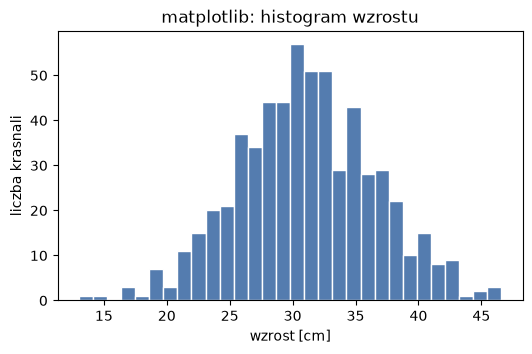

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(krasnale["wzrost_cm"], bins=30, color="#547CAF", edgecolor="white")
ax.set_xlabel("wzrost [cm]")
ax.set_ylabel("liczba krasnali")
ax.set_title("matplotlib: histogram wzrostu")
plt.show()

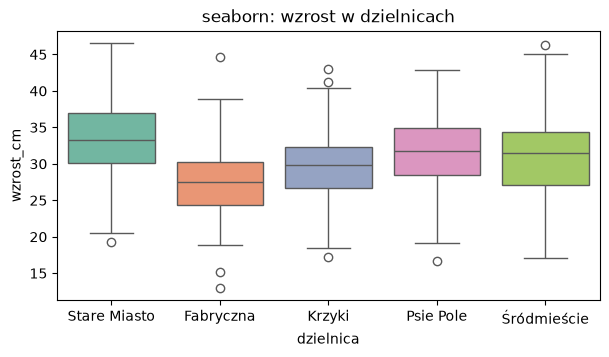

In [22]:
import seaborn as sns

plt.figure(figsize=(7, 3.5))
sns.boxplot(data=krasnale, x="dzielnica", y="wzrost_cm", hue="dzielnica", palette="Set2")
plt.title("seaborn: wzrost w dzielnicach")
plt.show()

In [23]:
import plotly.express as px

px.scatter(krasnale, x="rok_urodzenia", y="selfie_dziennie", color="dzielnica",
           hover_name="imie", title="plotly: najedź na punkt, żeby poznać krasnala")

### 🎯 Zadanie 5 (plotly)
Narysuj w **plotly** histogram wzrostu krasnali (`px.histogram`), w którym **każda dzielnica ma własny kolor**. Zapisz wykres w zmiennej `fig` i go wyświetl.

In [27]:
fig = px.histogram(krasnale, x="wzrost_cm", color="dzielnica") #TODO
fig

In [25]:
import plotly.graph_objects as go

assert isinstance(fig, go.Figure), "fig ma być wykresem plotly."
assert len(fig.data) == len(DZIELNICE), "Każda dzielnica powinna mieć osobny kolor (osobną serię)."
assert all(trace.type == "histogram" for trace in fig.data), "To ma być histogram."
zalicz(5)

✅ Zadanie 5 zaliczone! Gradientek z Psiego Pola macha czapeczką.


---
# Część 2: Flappy Krasnal (3 pkt)

Krasnal Bajtek zbudował latającą maszynę i chce przelecieć nad Wrocławiem przez szczeliny między kominami. Zasady:

- świat ma wysokość 10; krasnal startuje na wysokości 5 i co klatkę przesuwa się o 1 w prawo,
- co klatkę działa **grawitacja**: prędkość pionowa maleje o `GRAVITY`,
- gdy krasnal **skacze**, jego prędkość pionowa staje się równa sile skoku `flap`,
- kominy stoją co `SPACING` klatek; szczelina ma wysokość `GAP` i losową wysokość środka,
- krasnal rozbija się, gdy dotknie ziemi, nieba albo komina.

Krasnal sam nie myśli — skacze według **reguły** z trzema parametrami:
> skacz, gdy jesteś niżej niż *środek najbliższej szczeliny − `threshold`*, spadasz (prędkość ≤ 0) i od ostatniego skoku minęło co najmniej `cooldown` klatek.

Twoje zadanie: dobrać parametry `flap`, `threshold`, `cooldown` — najpierw ręcznie suwakami, potem automatycznie.

In [26]:
GRAVITY = 0.08      # grawitacji nie zmienisz, nawet we Wrocławiu
HEIGHT = 10.0       # wysokość świata
GAP = 1.8           # wysokość szczeliny
FIRST = 40          # w której klatce stoi pierwszy komin
SPACING = 26        # odstęp między kominami (w klatkach)
WIDTH = 4           # szerokość komina (w klatkach)
N_PIPES = 30


def make_world(seed, n_pipes=N_PIPES):
    # Wysokości środków szczelin dla jednego świata.
    return np.random.default_rng(seed).uniform(2.0, 8.0, n_pipes)


world0 = make_world(0)
print("środki pierwszych szczelin:", world0[:5].round(2))

środki pierwszych szczelin: [5.82 3.62 2.25 2.1  6.88]


### 🎯 Zadanie 6 (numpy/fizyka)
Napisz funkcję `step`, która wykonuje **jedną klatkę** ruchu krasnala:
- jeśli `jump` jest `True`: nowa prędkość `v = flap`,
- w przeciwnym razie: nowa prędkość `v = v - GRAVITY`,
- nowa wysokość: `y = y + v` (z **nową** prędkością).

Funkcja zwraca parę `(nowe_y, nowe_v)`.

In [ ]:
def step(y, v, jump, flap=0.4):
    ...  # TODO

In [ ]:
assert step(5.0, 0.0, False) is not None, "Funkcja nic nie zwraca — dodaj return."
y1, v1 = step(5.0, 0.0, False)
assert np.isclose(v1, -GRAVITY) and np.isclose(y1, 5.0 - GRAVITY), "Bez skoku: grawitacja zmniejsza prędkość, potem ruszamy krasnala."
y2, v2 = step(5.0, -1.0, True, flap=0.4)
assert np.isclose(v2, 0.4) and np.isclose(y2, 5.4), "Skok: prędkość staje się równa flap."
zalicz(6)

Pełna symulacja lotu używa dokładnie tej fizyki. Funkcja `simulate_python` zwraca: liczbę przelecianych kominów, klatkę katastrofy i wysokość krasnala w każdej klatce. Funkcja `draw_flight` rysuje lot. Wystarczy je uruchomić.

In [ ]:
def simulate_python(flap, threshold, cooldown, gaps):
    n_frames = FIRST + SPACING * len(gaps)
    ys = np.full(n_frames, np.nan)
    y, v, since, passed = 5.0, 0.0, 1000, 0
    for t in range(n_frames):
        # która szczelina jest następna?
        k = 0 if t < FIRST else (t - FIRST) // SPACING + ((t - FIRST) % SPACING >= WIDTH)
        k = min(k, len(gaps) - 1)
        if y < gaps[k] - threshold and v <= 0 and since >= cooldown:
            v = flap
            since = 0
        else:
            v = v - GRAVITY
            since += 1
        y = y + v
        ys[t] = y
        if y < 0 or y > HEIGHT:                       # ziemia albo niebo
            return passed, t, ys
        if t >= FIRST:
            j, off = (t - FIRST) // SPACING, (t - FIRST) % SPACING
            if off < WIDTH and abs(y - gaps[j]) > GAP / 2:   # komin!
                return passed, t, ys
            if off == WIDTH - 1:
                passed += 1
    return passed, n_frames, ys


def draw_flight(flap, threshold, cooldown, gaps, title=""):
    passed, crash, ys = simulate_python(flap, threshold, cooldown, gaps)
    view = min(len(ys), crash + 60)
    fig, ax = plt.subplots(figsize=(11, 3.2))
    for j, g in enumerate(gaps):
        x0 = FIRST + SPACING * j
        if x0 > view:
            break
        ax.add_patch(plt.Rectangle((x0, 0), WIDTH, g - GAP / 2, color="#8C979A"))
        ax.add_patch(plt.Rectangle((x0, g + GAP / 2), WIDTH, HEIGHT - g - GAP / 2, color="#8C979A"))
    ax.plot(np.arange(len(ys)), ys, color="#AD5149", lw=2)
    if crash < len(ys):
        ax.plot(crash, ys[crash], "x", color="black", ms=14, mew=3)
    ax.set_xlim(0, view)
    ax.set_ylim(0, HEIGHT)
    ax.set_xlabel("klatka")
    ax.set_title(title or f"Przelecianych kominów: {passed}" + (" — Wrocław zdobyty!" if passed == len(gaps) else ""))
    plt.show()
    return passed


draw_flight(flap=0.3, threshold=1.5, cooldown=1, gaps=world0)

## Widgety — suwaki zamiast przepisywania liczb

**ipywidgets** dodają do notebooka interaktywne kontrolki: suwaki, przyciski, listy. Najprostszy sposób to `interact`: podajesz funkcję i zakresy argumentów, a dostajesz suwaki. Każda zmiana suwaka uruchamia funkcję od nowa.

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact


def przywitaj(imie="Bajtek", ile_razy=2):
    print(("Cześć, " + imie + "! ") * ile_razy)


interact(przywitaj, imie=["Bajtek", "Gradientek", "Pierogeusz"], ile_razy=(1, 5));

### Steruj krasnalem!
Poruszaj suwakami i patrz, jak leci krasnal. `seed` zmienia świat (inne położenie szczelin).

In [ ]:
@interact(
    flap=widgets.FloatSlider(value=0.3, min=0.1, max=1.5, step=0.01, description="flap"),
    threshold=widgets.FloatSlider(value=1.5, min=-2.0, max=2.0, step=0.05, description="threshold"),
    cooldown=widgets.IntSlider(value=1, min=1, max=15, description="cooldown"),
    seed=widgets.IntSlider(value=0, min=0, max=9, description="seed"),
)
def fly(flap, threshold, cooldown, seed):
    draw_flight(flap, threshold, cooldown, make_world(seed))

### 🎯 Zadanie 7 (widgety)
Znajdź suwakami parametry, przy których krasnal w świecie `seed = 0` przelatuje **co najmniej 3 kominy**. Wpisz je do słownika `moje_parametry`.

Podpowiedź: to trudniejsze, niż wygląda. Zacznij od **słabego** skoku (`flap` w okolicy 0,4) i `threshold` bliskiego zera, potem poprawiaj po trochu.

🏅 **Bonus dla chwały (bez punktów):** przeleć ręcznie **10 kominów**. Pochwal się na zajęciach!

In [ ]:
moje_parametry = dict(flap=..., threshold=..., cooldown=...)  # TODO

In [ ]:
assert set(moje_parametry) == {"flap", "threshold", "cooldown"}, "Słownik ma mieć klucze flap, threshold, cooldown."
wynik = draw_flight(**moje_parametry, gaps=world0)
assert wynik >= 3, f"Tylko {wynik} kominów. Krasnal wierzy w Ciebie — spróbuj jeszcze!"
if wynik >= 10:
    print("🏅 10 kominów ręcznie! Legenda Rynku.")
zalicz(7)

### Bonus: film z lotu (widget `Play`)
Widget `Play` „klika” za Ciebie: co chwilę zwiększa numer klatki. Połączony z suwakiem tworzy animację. Uruchom i naciśnij ▶.

In [ ]:
_, crash, ys_film = simulate_python(**moje_parametry, gaps=world0)
frames = int(min(crash, len(ys_film) - 1))

play = widgets.Play(value=0, min=0, max=frames, step=2, interval=80)
frame = widgets.IntSlider(value=0, min=0, max=frames, description="klatka")
widgets.jslink((play, "value"), (frame, "value"))


def film(t):
    fig, ax = plt.subplots(figsize=(8, 2.8))
    for j, g in enumerate(world0):
        x0 = FIRST + SPACING * j
        ax.add_patch(plt.Rectangle((x0, 0), WIDTH, g - GAP / 2, color="#8C979A"))
        ax.add_patch(plt.Rectangle((x0, g + GAP / 2), WIDTH, HEIGHT - g - GAP / 2, color="#8C979A"))
    ax.plot(np.arange(t + 1), ys_film[: t + 1], color="#AD5149", lw=1.5, alpha=0.5)
    ax.plot(t, ys_film[t], "o", color="#DBA446", ms=14, mec="black")
    ax.set_xlim(t - 60, t + 40)
    ax.set_ylim(0, HEIGHT)
    plt.show()


display(widgets.HBox([play, frame]), widgets.interactive_output(film, {"t": frame}))

## numba — Python z prędkością C

Pętla `for` w czystym Pythonie jest wolna. **numba** kompiluje funkcję do kodu maszynowego przy pierwszym wywołaniu (*just-in-time*, JIT). Wystarczy dekorator `@njit` albo wywołanie `njit(funkcja)`. Działa najlepiej dla funkcji z pętlami na liczbach i tablicach numpy — dokładnie takich jak nasza symulacja.

### 🎯 Zadanie 8 (numba)
Utwórz `simulate_fast`: skompilowaną numbą wersję `simulate_python` (bez przepisywania jej kodu!). Komórka niżej zmierzy przyspieszenie.

In [ ]:
from numba import njit

simulate_fast = ...  # TODO

In [ ]:
assert hasattr(simulate_fast, "py_func"), "simulate_fast ma być funkcją skompilowaną przez numbę (njit)."
for s in range(5):
    w = make_world(s)
    assert simulate_fast(0.4, 0.6, 4, w)[:2] == simulate_python(0.4, 0.6, 4, w)[:2], "Wyniki różnią się od wersji w Pythonie!"

worlds = [make_world(s) for s in range(200)]
t = time.perf_counter(); [simulate_python(0.4, 0.6, 4, w) for w in worlds]; t_py = time.perf_counter() - t
t = time.perf_counter(); [simulate_fast(0.4, 0.6, 4, w) for w in worlds]; t_nb = time.perf_counter() - t
print(f"200 lotów: Python {t_py:.2f} s, numba {t_nb:.3f} s — {t_py / t_nb:.0f}× szybciej 🚀")
zalicz(8)

## Szukamy parametrów na ślepo: siatka + pandas

Z numbą stać nas na tysiące lotów. Sprawdźmy **siatkę** parametrów: każdą kombinację puszczamy w 20 światach i liczymy średnią liczbę kominów. Wyniki lądują w ramce danych pandas.

In [ ]:
import itertools

TRAIN_WORLDS = [make_world(s) for s in range(20)]


def score(flap, threshold, cooldown):
    # Średnia liczba przelecianych kominów w 20 światach.
    return np.mean([simulate_fast(flap, threshold, int(round(cooldown)), w)[0] for w in TRAIN_WORLDS])


rows = []
for flap, threshold, cooldown in itertools.product(np.linspace(0.1, 1.5, 8).round(2), np.linspace(-2, 2, 9).round(2), [1, 2, 4, 8]):
    rows.append({"flap": flap, "threshold": threshold, "cooldown": cooldown,
                 "rury": score(flap, threshold, cooldown)})
wyniki = pd.DataFrame(rows)
print(len(wyniki), "kombinacji")
wyniki.sort_values("rury", ascending=False).head()

### 🎯 Zadanie 9 (pandas)
Wybierz z ramki `wyniki` **wiersz z największą średnią liczbą kominów** (kolumna `rury`) i zapisz go w `najlepszy` (obiekt `Series`).

Podpowiedź: `idxmax()` zwraca indeks największej wartości, a `.loc[...]` wybiera wiersz.

In [ ]:
najlepszy = ...  # TODO
najlepszy

In [ ]:
assert isinstance(najlepszy, pd.Series), "najlepszy ma być jednym wierszem (Series)."
assert najlepszy["rury"] == wyniki["rury"].max(), "To nie jest najlepszy wiersz."
print(f"Najlepsza siatka: średnio {najlepszy['rury']:.1f} kominów.")
zalicz(9)

In [ ]:
# wizualizacja: jak wynik zależy od flap i threshold (dla najlepszego cooldown)
mapa = wyniki.pivot_table(index="threshold", columns="flap", values="rury", aggfunc="max")
plt.figure(figsize=(7, 4))
sns.heatmap(mapa.round(1), annot=True, fmt=".0f", cmap="Blues")
plt.title("seaborn: średnio przelecianych kominów (najlepszy cooldown)")
plt.show()

## scipy — matematyka w pudełku

**scipy** to zbiór gotowych algorytmów naukowych: optymalizacja, całkowanie, statystyka, przetwarzanie sygnałów, algebra liniowa. Tutaj użyjemy **optymalizacji**: zamiast sprawdzać siatkę, niech algorytm sam szuka najlepszych parametrów.

Nasz wynik zmienia się skokowo (liczba kominów to liczba całkowita), więc użyjemy `differential_evolution` — algorytmu ewolucyjnego, który nie potrzebuje pochodnych. `scipy.optimize` **minimalizuje**, więc podajemy mu *minus* wynik.

### 🎯 Zadanie 10 (scipy)
Wywołaj `differential_evolution` z funkcją `cel` i granicami `granice` (dodaj `seed=0` i `maxiter=40`). Zapisz wynik w `res`. Najlepsze parametry będą w `res.x`.

In [ ]:
from scipy.optimize import differential_evolution


def cel(x):
    flap, threshold, cooldown = x
    return -score(flap, threshold, cooldown)


granice = [(0.1, 1.5), (-2.0, 2.0), (1, 15)]   # flap, threshold, cooldown
res = ...  # TODO
res

In [ ]:
assert hasattr(res, "x") and len(res.x) == 3, "res ma być wynikiem optymalizacji z trzema parametrami."
assert all(lo <= v <= hi for v, (lo, hi) in zip(res.x, granice)), "Parametry wyszły poza granice."
wynik_scipy = score(*res.x)
assert wynik_scipy >= najlepszy["rury"], "Optymalizator przegrał z siatką? Sprawdź wywołanie."
print(f"scipy: średnio {wynik_scipy:.1f} kominów (siatka: {najlepszy['rury']:.1f}).")
zalicz(10)

In [ ]:
flap_s, threshold_s, cooldown_s = res.x
draw_flight(flap_s, threshold_s, int(round(cooldown_s)), make_world(123), title="Lot parametrami ze scipy w nowym świecie");

## scikit-learn — niech krasnal się nauczy

**scikit-learn** to najpopularniejsza biblioteka klasycznego uczenia maszynowego: dziesiątki modeli z tym samym interfejsem `fit` (ucz) i `predict` (przewiduj). Szczegóły poznasz na wykładzie — tu wystarczy intuicja.

Plan: krasnal-mistrz (parametry ze scipy) lata w wielu światach, a my **zapisujemy** każdą jego decyzję: w jakiej był sytuacji (cechy) i czy skoczył (etykieta). Potem uczymy **drzewo decyzyjne** naśladować mistrza. Tak powstaje **autopilot**.

In [ ]:
def fly_with_policy(policy, gaps, log=None):
    # Lot, w którym o skoku decyduje funkcja policy(dy, v, since) -> True/False.
    n_frames = FIRST + SPACING * len(gaps)
    y, v, since, passed = 5.0, 0.0, 1000, 0
    for t in range(n_frames):
        k = 0 if t < FIRST else (t - FIRST) // SPACING + ((t - FIRST) % SPACING >= WIDTH)
        k = min(k, len(gaps) - 1)
        state = (y - gaps[k], v, min(since, 20))
        jump = bool(policy(*state))
        if log is not None:
            log.append((*state, jump))
        if jump:
            v, since = flap_s, 0
        else:
            v, since = v - GRAVITY, since + 1
        y += v
        if y < 0 or y > HEIGHT:
            return passed
        if t >= FIRST:
            j, off = (t - FIRST) // SPACING, (t - FIRST) % SPACING
            if off < WIDTH and abs(y - gaps[j]) > GAP / 2:
                return passed
            if off == WIDTH - 1:
                passed += 1
    return passed


def master(dy, v, since):
    return dy < -threshold_s and v <= 0 and since >= int(round(cooldown_s))


log = []
for s in range(30):
    fly_with_policy(master, make_world(1000 + s), log)
dane = pd.DataFrame(log, columns=["dy", "v", "since", "skok"])
print(dane.shape)
dane.sample(5, random_state=0)

### 🎯 Zadanie 11 (scikit-learn)
1. Podziel dane na treningowe i testowe: `train_test_split(X, y, test_size=0.25, random_state=0)`.
2. Naucz `DecisionTreeClassifier(max_depth=5)` na danych treningowych (`fit`).
3. Zapisz model w `autopilot`, a trafność na zbiorze testowym (`autopilot.score(...)`) w `trafnosc`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = dane[["dy", "v", "since"]].to_numpy()
y = dane["skok"].to_numpy()

# TODO: podział, uczenie, trafność
autopilot = ...
trafnosc = ...
print(f"trafność: {trafnosc}")

In [ ]:
assert hasattr(autopilot, "predict"), "autopilot ma być nauczonym modelem scikit-learn."
assert 0.95 <= trafnosc <= 1.0, f"Trafność {trafnosc} — autopilot słabo naśladuje mistrza."


def autopilot_policy(dy, v, since):
    return autopilot.predict([[dy, v, since]])[0]


rury_auto = fly_with_policy(autopilot_policy, make_world(7))
print(f"Autopilot przeleciał {rury_auto} kominów w nieznanym świecie.")
assert rury_auto >= 10, "Autopilot rozbił się za szybko."
zalicz(11)

🏅 **Bonus dla chwały:** zmniejsz szczelinę (`GAP = 1.5` w komórce z zasadami gry) i uruchom część 2 od nowa. Czy scipy i autopilot dalej dają radę? Popraw je: inne granice, więcej światów treningowych, inny model (`max_depth`, inny klasyfikator). Pochwal się wynikiem na zajęciach.

---
## Podsumowanie punktów
Uruchom na końcu i pokaż prowadzącemu.

In [ ]:
czesci = {1: 2, 2: 3}   # część -> punkty
razem = 0
for czesc, pkt in czesci.items():
    wszystkie = {nr for nr, c in ZADANIA.items() if c == czesc}
    zrobione = wszystkie & ZALICZONE
    ok = zrobione == wszystkie
    razem += pkt if ok else 0
    braki = sorted(wszystkie - zrobione)
    print(f"Część {czesc}: {len(zrobione)}/{len(wszystkie)} zadań → {pkt if ok else 0} pkt"
          + ("" if ok else f"  (brakuje: {braki})"))
print(f"\nRazem: {razem} / 5 pkt bonusowych" + (" 🎉 Krasnale śpiewają hymn na Rynku!" if razem == 5 else ""))